# HW07: Кластеризация и внутренние метрики качества



In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Кластеризация
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Метрики качества кластеризации
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Для визуализации
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Настройка отображения
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Библиотеки загружены успешно!")


Библиотеки загружены успешно!


## 2.3.1. Загрузка данных и первичный анализ

Для каждого из 3 выбранных CSV выполним:
1. Загрузку данных
2. Базовый EDA (head, info, describe, проверка пропусков, типы признаков)
3. Определение X (признаки) и sample_id


### Датасет 01: S07-hw-dataset-01.csv


In [9]:
# Загрузка датасета 01
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')

print("=" * 60)
print("ДАТАСЕТ 01: Базовая информация")
print("=" * 60)
print(f"\nРазмерность данных: {df1.shape}")
print(f"Количество строк: {df1.shape[0]}")
print(f"Количество столбцов: {df1.shape[1]}")

print("\n" + "=" * 60)
print("Первые строки (head):")
print("=" * 60)
print(df1.head())


ДАТАСЕТ 01: Базовая информация

Размерность данных: (12000, 9)
Количество строк: 12000
Количество столбцов: 9

Первые строки (head):
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  


In [10]:
print("\n" + "=" * 60)
print("Информация о данных (info):")
print("=" * 60)
df1.info()



Информация о данных (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [11]:
print("\n" + "=" * 60)
print("Базовые статистики (describe):")
print("=" * 60)
print(df1.describe())



Базовые статистики (describe):
         sample_id           f01           f02           f03           f04  \
count  12000.00000  12000.000000  12000.000000  12000.000000  12000.000000   
mean    5999.50000     -2.424716     19.107804     -0.222063     -8.284501   
std     3464.24595     11.014315     60.790338      0.500630     59.269838   
min        0.00000    -19.912573    -92.892652     -1.590979   -134.303679   
25%     2999.75000     -9.472623    -40.282955     -0.125145    -48.345007   
50%     5999.50000     -6.869404     54.069335     -0.031753     16.211728   
75%     8999.25000      0.523841     70.280739      0.054980     28.067178   
max    11999.00000     24.403381    112.229523      0.512277     75.088604   

                f05           f06           f07           f08  
count  12000.000000  12000.000000  12000.000000  12000.000000  
mean      -0.190717      0.962972      0.033724      0.007638  
std        7.026435     14.794713     59.541782      0.607053  
min      

In [12]:
print("\n" + "=" * 60)
print("Проверка пропусков:")
print("=" * 60)
missing_count = df1.isnull().sum()
missing_pct = (missing_count / len(df1)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Доля пропусков (%)': missing_pct.round(2)
})
print(missing_df)
print(f"\nВсего пропусков: {missing_count.sum()}")



Проверка пропусков:
           Количество пропусков  Доля пропусков (%)
sample_id                     0                 0.0
f01                           0                 0.0
f02                           0                 0.0
f03                           0                 0.0
f04                           0                 0.0
f05                           0                 0.0
f06                           0                 0.0
f07                           0                 0.0
f08                           0                 0.0

Всего пропусков: 0


In [13]:
print("\n" + "=" * 60)
print("Типы признаков:")
print("=" * 60)
# Определяем типы признаков
numeric_cols = df1.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df1.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки ({len(numeric_cols)}): {numeric_cols}")
print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols if categorical_cols else 'Нет'}")

# Исключаем sample_id из признаков
feature_cols = [col for col in numeric_cols if col != 'sample_id']
print(f"\nПризнаки для моделирования (без sample_id): {feature_cols}")

# Определяем X и sample_id
sample_id_1 = df1['sample_id'].copy()
X1 = df1[feature_cols].copy()

print(f"\nX1.shape: {X1.shape}")
print(f"sample_id_1.shape: {sample_id_1.shape}")



Типы признаков:
Числовые признаки (9): ['sample_id', 'f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Категориальные признаки (0): Нет

Признаки для моделирования (без sample_id): ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']

X1.shape: (12000, 8)
sample_id_1.shape: (12000,)


### Датасет 02: S07-hw-dataset-02.csv


In [19]:
# Загрузка датасета 02
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')

print("=" * 60)
print("ДАТАСЕТ 02: Базовая информация")
print("=" * 60)
print(f"\nРазмерность данных: {df2.shape}")
print(f"Количество строк: {df2.shape[0]}")
print(f"Количество столбцов: {df2.shape[1]}")

print("\n" + "=" * 60)
print("Первые строки (head):")
print("=" * 60)
print(df2.head())


ДАТАСЕТ 02: Базовая информация

Размерность данных: (8000, 4)
Количество строк: 8000
Количество столбцов: 4

Первые строки (head):
   sample_id        x1        x2    z_noise
0          0  0.098849 -1.846034  21.288122
1          1 -1.024516  1.829616   6.072952
2          2 -1.094178 -0.158545 -18.938342
3          3 -1.612808 -1.565844 -11.629462
4          4  1.659901 -2.133292   1.895472


In [24]:
print("\n" + "=" * 60)
print("Информация о данных (info):")
print("=" * 60)
df2.info()



Информация о данных (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [26]:
print("\n" + "=" * 60)
print("Базовые статистики (describe):")
print("=" * 60)
print(df2.describe())



Базовые статистики (describe):
        sample_id           x1           x2      z_noise
count  8000.00000  8000.000000  8000.000000  8000.000000
mean   3999.50000     0.478867     0.241112     0.110454
std    2309.54541     0.955138     0.663195     8.097716
min       0.00000    -2.487352    -2.499237   -34.056074
25%    1999.75000    -0.116516    -0.242357    -5.392210
50%    3999.50000     0.490658     0.241092     0.132470
75%    5999.25000     1.085263     0.726526     5.655605
max    7999.00000     2.987555     2.995553    29.460076


In [27]:
print("\n" + "=" * 60)
print("Проверка пропусков:")
print("=" * 60)
missing_count = df2.isnull().sum()
missing_pct = (missing_count / len(df2)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Доля пропусков (%)': missing_pct.round(2)
})
print(missing_df)
print(f"\nВсего пропусков: {missing_count.sum()}")



Проверка пропусков:
           Количество пропусков  Доля пропусков (%)
sample_id                     0                 0.0
x1                            0                 0.0
x2                            0                 0.0
z_noise                       0                 0.0

Всего пропусков: 0


In [28]:
print("\n" + "=" * 60)
print("Типы признаков:")
print("=" * 60)
# Определяем типы признаков
numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df2.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки ({len(numeric_cols)}): {numeric_cols}")
print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols if categorical_cols else 'Нет'}")

# Исключаем sample_id из признаков
feature_cols = [col for col in numeric_cols if col != 'sample_id']
print(f"\nПризнаки для моделирования (без sample_id): {feature_cols}")

# Определяем X и sample_id
sample_id_2 = df2['sample_id'].copy()
X2 = df2[feature_cols].copy()

print(f"\nX2.shape: {X2.shape}")
print(f"sample_id_2.shape: {sample_id_2.shape}")



Типы признаков:
Числовые признаки (4): ['sample_id', 'x1', 'x2', 'z_noise']
Категориальные признаки (0): Нет

Признаки для моделирования (без sample_id): ['x1', 'x2', 'z_noise']

X2.shape: (8000, 3)
sample_id_2.shape: (8000,)


### Датасет 03: S07-hw-dataset-03.csv


In [29]:
# Загрузка датасета 03
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')

print("=" * 60)
print("ДАТАСЕТ 03: Базовая информация")
print("=" * 60)
print(f"\nРазмерность данных: {df3.shape}")
print(f"Количество строк: {df3.shape[0]}")
print(f"Количество столбцов: {df3.shape[1]}")

print("\n" + "=" * 60)
print("Первые строки (head):")
print("=" * 60)
print(df3.head())


ДАТАСЕТ 03: Базовая информация

Размерность данных: (15000, 5)
Количество строк: 15000
Количество столбцов: 5

Первые строки (head):
   sample_id        x1        x2    f_corr   f_noise
0          0 -2.710470  4.997107 -1.015703  0.718508
1          1  8.730238 -8.787416  3.953063 -1.105349
2          2 -1.079600 -2.558708  0.976628 -3.605776
3          3  6.854042  1.560181  1.760614 -1.230946
4          4  9.963812 -8.869921  2.966583  0.915899


In [30]:
print("\n" + "=" * 60)
print("Информация о данных (info):")
print("=" * 60)
df3.info()



Информация о данных (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [31]:
print("\n" + "=" * 60)
print("Базовые статистики (describe):")
print("=" * 60)
print(df3.describe())



Базовые статистики (describe):
          sample_id            x1            x2        f_corr       f_noise
count  15000.000000  15000.000000  15000.000000  15000.000000  15000.000000
mean    7499.500000      1.246296      1.033764      0.212776     -0.027067
std     4330.271354      4.592421      4.710791      1.530017      2.506375
min        0.000000     -9.995585     -9.980853     -5.212038     -8.785884
25%     3749.750000     -1.782144     -2.666393     -0.966224     -1.731128
50%     7499.500000      0.664226      1.831257      0.296508     -0.052391
75%    11249.250000      4.435671      4.969630      1.390273      1.673831
max    14999.000000     16.207863     14.271153      5.795876     11.266865


In [32]:
print("\n" + "=" * 60)
print("Проверка пропусков:")
print("=" * 60)
missing_count = df3.isnull().sum()
missing_pct = (missing_count / len(df3)) * 100
missing_df = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Доля пропусков (%)': missing_pct.round(2)
})
print(missing_df)
print(f"\nВсего пропусков: {missing_count.sum()}")



Проверка пропусков:
           Количество пропусков  Доля пропусков (%)
sample_id                     0                 0.0
x1                            0                 0.0
x2                            0                 0.0
f_corr                        0                 0.0
f_noise                       0                 0.0

Всего пропусков: 0


In [33]:
print("\n" + "=" * 60)
print("Типы признаков:")
print("=" * 60)
# Определяем типы признаков
numeric_cols = df3.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df3.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Числовые признаки ({len(numeric_cols)}): {numeric_cols}")
print(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols if categorical_cols else 'Нет'}")

# Исключаем sample_id из признаков
feature_cols = [col for col in numeric_cols if col != 'sample_id']
print(f"\nПризнаки для моделирования (без sample_id): {feature_cols}")

# Определяем X и sample_id
sample_id_3 = df3['sample_id'].copy()
X3 = df3[feature_cols].copy()

print(f"\nX3.shape: {X3.shape}")
print(f"sample_id_3.shape: {sample_id_3.shape}")



Типы признаков:
Числовые признаки (5): ['sample_id', 'x1', 'x2', 'f_corr', 'f_noise']
Категориальные признаки (0): Нет

Признаки для моделирования (без sample_id): ['x1', 'x2', 'f_corr', 'f_noise']

X3.shape: (15000, 4)
sample_id_3.shape: (15000,)


## 2.3.2. Препроцессинг

Для каждого датасета оформим препроцессинг **явно** с использованием Pipeline/ColumnTransformer.

**Минимум:**
- Масштабирование числовых признаков: `StandardScaler`
- Если есть пропуски – обработать (`SimpleImputer`)
- Если есть категориальные признаки – закодировать (`OneHotEncoder`)

**Примечание:** Для выбранных датасетов (01, 02, 03) все признаки числовые и пропусков нет, но структура препроцессинга позволит легко добавить обработку пропусков и категориальных признаков при необходимости.


### Препроцессинг для Датасета 01


In [34]:
# Создаём пайплайн препроцессинга
# Структура: Imputer (на случай пропусков) -> StandardScaler
# Для данного датасета пропусков нет, но оставляем структуру для универсальности

preprocessor_1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # На случай пропусков
    ('scaler', StandardScaler())
])

print("Создан препроцессор для датасета 01:")
print(f"Признаки: {X1.columns.tolist()}")
print(f"Размерность до препроцессинга: {X1.shape}")

# Применяем препроцессинг
X1_processed = preprocessor_1.fit_transform(X1)

print(f"Размерность после препроцессинга: {X1_processed.shape}")
print(f"\nПервые 5 строк после масштабирования:")
print(X1_processed[:5])

# Проверяем статистики после масштабирования
print(f"\nСтатистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):")
print(f"Среднее по признакам: {X1_processed.mean(axis=0).round(6)}")
print(f"Стандартное отклонение по признакам: {X1_processed.std(axis=0).round(6)}")


Создан препроцессор для датасета 01:
Признаки: ['f01', 'f02', 'f03', 'f04', 'f05', 'f06', 'f07', 'f08']
Размерность до препроцессинга: (12000, 8)
Размерность после препроцессинга: (12000, 8)

Первые 5 строк после масштабирования:
[[ 0.17142668 -1.46280499  0.43827875  1.35028177 -1.5948697  -0.89591542
  -0.11539556 -0.84301268]
 [ 1.60302144  0.55306178 -2.1005838  -1.61705848  1.67664705  2.2545476
  -0.83142723  0.6304788 ]
 [ 1.90373017  0.95758263 -2.19656934 -1.74905918  1.48660018  1.68513022
   0.74843886  0.52428406]
 [-0.91831503 -1.00048459  0.73617818  0.41517997  0.22513839  0.07106513
  -0.67122564  0.21689135]
 [-0.40660969  0.70286533  0.39870815 -0.57952352  0.46937156 -0.43490498
   0.11702228  0.20357459]]

Статистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):
Среднее по признакам: [-0. -0. -0. -0. -0. -0. -0. -0.]
Стандартное отклонение по признакам: [1. 1. 1. 1. 1. 1. 1. 1.]


### Препроцессинг для Датасета 02


In [35]:
preprocessor_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # На случай пропусков
    ('scaler', StandardScaler())
])

print("Создан препроцессор для датасета 02:")
print(f"Признаки: {X2.columns.tolist()}")
print(f"Размерность до препроцессинга: {X2.shape}")

# Применяем препроцессинг
X2_processed = preprocessor_2.fit_transform(X2)

print(f"Размерность после препроцессинга: {X2_processed.shape}")
print(f"\nПервые 5 строк после масштабирования:")
print(X2_processed[:5])

# Проверяем статистики после масштабирования
print(f"\nСтатистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):")
print(f"Среднее по признакам: {X2_processed.mean(axis=0).round(6)}")
print(f"Стандартное отклонение по признакам: {X2_processed.std(axis=0).round(6)}")


Создан препроцессор для датасета 02:
Признаки: ['x1', 'x2', 'z_noise']
Размерность до препроцессинга: (8000, 3)
Размерность после препроцессинга: (8000, 3)

Первые 5 строк после масштабирования:
[[-0.39789177 -3.14730563  2.61542782]
 [-1.57409478  2.39537899  0.7363646 ]
 [-1.64703263 -0.60266152 -2.35251356]
 [-2.19005641 -2.72479336 -1.4498717 ]
 [ 1.23658383 -3.58047513  0.22044856]]

Статистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):
Среднее по признакам: [-0.  0. -0.]
Стандартное отклонение по признакам: [1. 1. 1.]


### Препроцессинг для Датасета 03


In [36]:
# Препроцессинг для датасета 03
# Все признаки числовые, пропусков нет

preprocessor_3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # На случай пропусков
    ('scaler', StandardScaler())
])

print("Создан препроцессор для датасета 03:")
print(f"Признаки: {X3.columns.tolist()}")
print(f"Размерность до препроцессинга: {X3.shape}")

# Применяем препроцессинг
X3_processed = preprocessor_3.fit_transform(X3)

print(f"Размерность после препроцессинга: {X3_processed.shape}")
print(f"\nПервые 5 строк после масштабирования:")
print(X3_processed[:5])

# Проверяем статистики после масштабирования
print(f"\nСтатистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):")
print(f"Среднее по признакам: {X3_processed.mean(axis=0).round(6)}")
print(f"Стандартное отклонение по признакам: {X3_processed.std(axis=0).round(6)}")


Создан препроцессор для датасета 03:
Признаки: ['x1', 'x2', 'f_corr', 'f_noise']
Размерность до препроцессинга: (15000, 4)
Размерность после препроцессинга: (15000, 4)

Первые 5 строк после масштабирования:
[[-0.86161489  0.84136075 -0.80294603  0.29748161]
 [ 1.62968311 -2.08489576  2.44468683 -0.43022975]
 [-0.50648098 -0.7626304   0.4992609  -1.42788996]
 [ 1.22112761  0.1117507   1.01168106 -0.48034263]
 [ 1.89830286 -2.10241032  1.79991419  0.37623961]]

Статистики после масштабирования (должны быть ~0 среднее, ~1 ст.откл.):
Среднее по признакам: [ 0. -0.  0. -0.]
Стандартное отклонение по признакам: [1. 1. 1. 1.]


**Итог препроцессинга:**

- Для всех трёх датасетов применён `StandardScaler` для масштабирования числовых признаков
- В пайплайн включён `SimpleImputer` (на случай пропусков), хотя в данных их нет
- Все препроцессоры сохранены и готовы для применения к тестовым данным (если потребуется)
- Обработанные данные (`X1_processed`, `X2_processed`, `X3_processed`) готовы для кластеризации


### Датасет 01: Кластеризация и метрики


#### 1. KMeans для Датасета 01


In [38]:
# Подбор оптимального k для KMeans на датасете 01
k_range = range(2, 21)
kmeans_scores = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

print("Подбор параметра k для KMeans (Датасет 01)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X1_processed)
    
    # Исключаем случаи, когда все точки в одном кластере
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        continue
    
    silhouette = silhouette_score(X1_processed, labels)
    db = davies_bouldin_score(X1_processed, labels)
    ch = calinski_harabasz_score(X1_processed, labels)
    
    kmeans_scores['k'].append(k)
    kmeans_scores['silhouette'].append(silhouette)
    kmeans_scores['davies_bouldin'].append(db)
    kmeans_scores['calinski_harabasz'].append(ch)

kmeans_df1 = pd.DataFrame(kmeans_scores)
print("\nТоп-5 значений по silhouette score:")
print(kmeans_df1.nlargest(5, 'silhouette')[['k', 'silhouette', 'davies_bouldin', 'calinski_harabasz']])

# Выбираем оптимальное k (по максимуму silhouette)
best_k1 = kmeans_df1.loc[kmeans_df1['silhouette'].idxmax(), 'k']
print(f"\nОптимальное k: {int(best_k1)} (silhouette = {kmeans_df1['silhouette'].max():.4f})")

# Обучаем финальную модель
kmeans_1 = KMeans(n_clusters=int(best_k1), random_state=42, n_init=10, max_iter=300)
labels_kmeans_1 = kmeans_1.fit_predict(X1_processed)


Подбор параметра k для KMeans (Датасет 01)...

Топ-5 значений по silhouette score:
   k  silhouette  davies_bouldin  calinski_harabasz
0  2    0.521640        0.685330       11786.954623
1  3    0.396758        0.964604       10446.638111
2  4    0.383301        1.160349        9427.499744
4  6    0.358561        1.182256        7333.387619
3  5    0.354801        1.273719        8301.205994

Оптимальное k: 2 (silhouette = 0.5216)


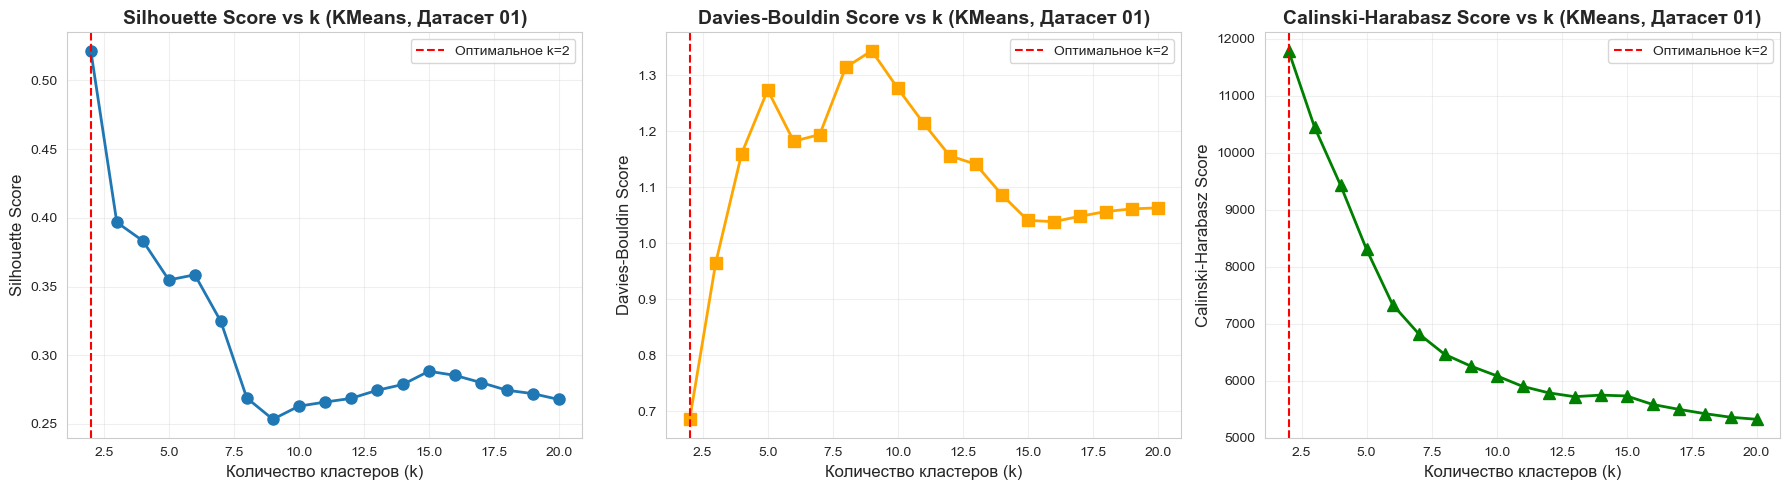

In [39]:
# График метрик vs k для KMeans (Датасет 01)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(kmeans_df1['k'], kmeans_df1['silhouette'], marker='o', linewidth=2, markersize=8)
axes[0].axvline(x=best_k1, color='r', linestyle='--', label=f'Оптимальное k={int(best_k1)}')
axes[0].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_title('Silhouette Score vs k (KMeans, Датасет 01)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(kmeans_df1['k'], kmeans_df1['davies_bouldin'], marker='s', color='orange', linewidth=2, markersize=8)
axes[1].axvline(x=best_k1, color='r', linestyle='--', label=f'Оптимальное k={int(best_k1)}')
axes[1].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1].set_title('Davies-Bouldin Score vs k (KMeans, Датасет 01)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(kmeans_df1['k'], kmeans_df1['calinski_harabasz'], marker='^', color='green', linewidth=2, markersize=8)
axes[2].axvline(x=best_k1, color='r', linestyle='--', label=f'Оптимальное k={int(best_k1)}')
axes[2].set_xlabel('Количество кластеров (k)', fontsize=12)
axes[2].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[2].set_title('Calinski-Harabasz Score vs k (KMeans, Датасет 01)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.savefig('artifacts/figures/dataset01_kmeans_metrics.png', dpi=300, bbox_inches='tight')
plt.show()


#### 2. DBSCAN для Датасета 01


In [40]:
# Подбор параметров DBSCAN для датасета 01
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = [3, 5, 7, 10]

dbscan_results_1 = []

print("Подбор параметров DBSCAN для Датасета 01...")
print(f"Проверяем eps в диапазоне: {eps_range.min():.1f} - {eps_range.max():.1f}")
print(f"min_samples: {min_samples_range}\n")

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X1_processed)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # Пропускаем, если слишком мало кластеров или слишком много шума
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
        
        # Вычисляем метрики только на non-noise точках
        non_noise_mask = labels != -1
        if non_noise_mask.sum() < 10:  # Нужно минимум точек для метрик
            continue
        
        X_non_noise = X1_processed[non_noise_mask]
        labels_non_noise = labels[non_noise_mask]
        
        if len(set(labels_non_noise)) < 2:
            continue
        
        silhouette = silhouette_score(X_non_noise, labels_non_noise)
        db = davies_bouldin_score(X_non_noise, labels_non_noise)
        ch = calinski_harabasz_score(X_non_noise, labels_non_noise)
        
        dbscan_results_1.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

dbscan_df1 = pd.DataFrame(dbscan_results_1)
if len(dbscan_df1) > 0:
    print(f"Найдено {len(dbscan_df1)} валидных комбинаций параметров")
    print("\nТоп-5 по silhouette score:")
    print(dbscan_df1.nlargest(5, 'silhouette')[['eps', 'min_samples', 'n_clusters', 'noise_ratio', 
                                                'silhouette', 'davies_bouldin']])
    
    # Выбираем лучшую комбинацию (по максимуму silhouette, но с учетом разумного noise_ratio)
    best_idx = dbscan_df1.loc[dbscan_df1['noise_ratio'] < 0.3, 'silhouette'].idxmax()
    if pd.isna(best_idx):
        best_idx = dbscan_df1['silhouette'].idxmax()
    
    best_eps_1 = dbscan_df1.loc[best_idx, 'eps']
    best_min_samples_1 = int(dbscan_df1.loc[best_idx, 'min_samples'])
    
    print(f"\nОптимальные параметры: eps={best_eps_1:.1f}, min_samples={best_min_samples_1}")
    
    # Обучаем финальную модель
    dbscan_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
    labels_dbscan_1 = dbscan_1.fit_predict(X1_processed)
    
    n_noise_final = list(labels_dbscan_1).count(-1)
    print(f"Доля шума в финальной модели: {n_noise_final/len(labels_dbscan_1):.2%}")
else:
    print("Не удалось найти подходящие параметры DBSCAN для данного датасета")
    # Используем значения по умолчанию
    best_eps_1, best_min_samples_1 = 0.5, 5
    dbscan_1 = DBSCAN(eps=best_eps_1, min_samples=best_min_samples_1)
    labels_dbscan_1 = dbscan_1.fit_predict(X1_processed)


Подбор параметров DBSCAN для Датасета 01...
Проверяем eps в диапазоне: 0.1 - 1.4
min_samples: [3, 5, 7, 10]

Найдено 46 валидных комбинаций параметров

Топ-5 по silhouette score:
    eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin
42  1.4            3           3     0.000083    0.396859        0.964292
43  1.4            5           3     0.000083    0.396859        0.964292
44  1.4            7           3     0.000083    0.396859        0.964292
45  1.4           10           3     0.000083    0.396859        0.964292
13  0.6           10           5     0.019167    0.384532        1.239746

Оптимальные параметры: eps=1.4, min_samples=3
Доля шума в финальной модели: 0.01%


#### 3. AgglomerativeClustering для Датасета 01


In [41]:
# Подбор параметров AgglomerativeClustering для датасета 01
linkage_types = ['ward', 'complete', 'average']
k_range_agg = range(2, 21)

agg_results_1 = []

print("Подбор параметров AgglomerativeClustering для Датасета 01...")
print(f"Linkage типы: {linkage_types}")
print(f"Диапазон k: {min(k_range_agg)} - {max(k_range_agg)}\n")

for linkage in linkage_types:
    for k in k_range_agg:
        try:
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X1_processed)
            
            silhouette = silhouette_score(X1_processed, labels)
            db = davies_bouldin_score(X1_processed, labels)
            ch = calinski_harabasz_score(X1_processed, labels)
            
            agg_results_1.append({
                'linkage': linkage,
                'n_clusters': k,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch
            })
        except Exception as e:
            # ward работает только с euclidean, может быть проблема
            continue

agg_df1 = pd.DataFrame(agg_results_1)
print(f"Оценено {len(agg_df1)} комбинаций параметров")

# Лучшие результаты по каждому linkage
for linkage in linkage_types:
    linkage_df = agg_df1[agg_df1['linkage'] == linkage]
    if len(linkage_df) > 0:
        best_row = linkage_df.loc[linkage_df['silhouette'].idxmax()]
        print(f"\n{linkage.upper()}: лучший k={int(best_row['n_clusters'])}, silhouette={best_row['silhouette']:.4f}")

# Выбираем лучшую комбинацию
best_agg_row_1 = agg_df1.loc[agg_df1['silhouette'].idxmax()]
best_linkage_1 = best_agg_row_1['linkage']
best_k_agg_1 = int(best_agg_row_1['n_clusters'])

print(f"\nОптимальные параметры: linkage='{best_linkage_1}', n_clusters={best_k_agg_1}")

# Обучаем финальную модель
agg_1 = AgglomerativeClustering(n_clusters=best_k_agg_1, linkage=best_linkage_1)
labels_agg_1 = agg_1.fit_predict(X1_processed)


Подбор параметров AgglomerativeClustering для Датасета 01...
Linkage типы: ['ward', 'complete', 'average']
Диапазон k: 2 - 20

Оценено 57 комбинаций параметров

WARD: лучший k=2, silhouette=0.5216

COMPLETE: лучший k=2, silhouette=0.5216

AVERAGE: лучший k=2, silhouette=0.5216

Оптимальные параметры: linkage='ward', n_clusters=2


#### Сравнение метрик для Датасета 01


In [42]:
# Сводная таблица метрик для Датасета 01
metrics_summary_1 = []

# KMeans метрики
non_noise_kmeans = labels_kmeans_1 != -1  # Всегда True для KMeans, но для единообразия
metrics_summary_1.append({
    'Алгоритм': 'KMeans',
    'Параметры': f'k={int(best_k1)}',
    'Silhouette': silhouette_score(X1_processed, labels_kmeans_1),
    'Davies-Bouldin': davies_bouldin_score(X1_processed, labels_kmeans_1),
    'Calinski-Harabasz': calinski_harabasz_score(X1_processed, labels_kmeans_1),
    'Доля шума': 0.0
})

# DBSCAN метрики (на non-noise точках)
non_noise_dbscan = labels_dbscan_1 != -1
if non_noise_dbscan.sum() > 0 and len(set(labels_dbscan_1[non_noise_dbscan])) >= 2:
    X_dbscan_non_noise = X1_processed[non_noise_dbscan]
    labels_dbscan_non_noise = labels_dbscan_1[non_noise_dbscan]
    noise_ratio_dbscan = (~non_noise_dbscan).sum() / len(labels_dbscan_1)
    
    metrics_summary_1.append({
        'Алгоритм': 'DBSCAN',
        'Параметры': f'eps={best_eps_1:.1f}, min_samples={best_min_samples_1}',
        'Silhouette': silhouette_score(X_dbscan_non_noise, labels_dbscan_non_noise),
        'Davies-Bouldin': davies_bouldin_score(X_dbscan_non_noise, labels_dbscan_non_noise),
        'Calinski-Harabasz': calinski_harabasz_score(X_dbscan_non_noise, labels_dbscan_non_noise),
        'Доля шума': noise_ratio_dbscan
    })

# Agglomerative метрики
metrics_summary_1.append({
    'Алгоритм': 'AgglomerativeClustering',
    'Параметры': f'linkage={best_linkage_1}, k={best_k_agg_1}',
    'Silhouette': silhouette_score(X1_processed, labels_agg_1),
    'Davies-Bouldin': davies_bouldin_score(X1_processed, labels_agg_1),
    'Calinski-Harabasz': calinski_harabasz_score(X1_processed, labels_agg_1),
    'Доля шума': 0.0
})

metrics_df1 = pd.DataFrame(metrics_summary_1)
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 01")
print("=" * 80)
print(metrics_df1.to_string(index=False))
print("\nПримечание: Для DBSCAN метрики рассчитаны только на non-noise точках.")


СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 01
               Алгоритм              Параметры  Silhouette  Davies-Bouldin  Calinski-Harabasz  Доля шума
                 KMeans                    k=2    0.521640        0.685330       11786.954623   0.000000
                 DBSCAN eps=1.4, min_samples=3    0.396859        0.964292       10451.506805   0.000083
AgglomerativeClustering      linkage=ward, k=2    0.521640        0.685330       11786.954623   0.000000

Примечание: Для DBSCAN метрики рассчитаны только на non-noise точках.


### Датасет 02: Кластеризация и метрики


In [43]:
# KMeans для Датасета 02
k_range = range(2, 21)
kmeans_scores_2 = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

print("Подбор параметра k для KMeans (Датасет 02)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X2_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        continue
    
    silhouette = silhouette_score(X2_processed, labels)
    db = davies_bouldin_score(X2_processed, labels)
    ch = calinski_harabasz_score(X2_processed, labels)
    
    kmeans_scores_2['k'].append(k)
    kmeans_scores_2['silhouette'].append(silhouette)
    kmeans_scores_2['davies_bouldin'].append(db)
    kmeans_scores_2['calinski_harabasz'].append(ch)

kmeans_df2 = pd.DataFrame(kmeans_scores_2)
best_k2 = kmeans_df2.loc[kmeans_df2['silhouette'].idxmax(), 'k']
print(f"Оптимальное k: {int(best_k2)} (silhouette = {kmeans_df2['silhouette'].max():.4f})")

kmeans_2 = KMeans(n_clusters=int(best_k2), random_state=42, n_init=10, max_iter=300)
labels_kmeans_2 = kmeans_2.fit_predict(X2_processed)


Подбор параметра k для KMeans (Датасет 02)...
Оптимальное k: 2 (silhouette = 0.3069)


In [44]:
# DBSCAN для Датасета 02
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = [3, 5, 7, 10]
dbscan_results_2 = []

print("Подбор параметров DBSCAN для Датасета 02...")
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X2_processed)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
        
        non_noise_mask = labels != -1
        if non_noise_mask.sum() < 10:
            continue
        
        X_non_noise = X2_processed[non_noise_mask]
        labels_non_noise = labels[non_noise_mask]
        
        if len(set(labels_non_noise)) < 2:
            continue
        
        silhouette = silhouette_score(X_non_noise, labels_non_noise)
        db = davies_bouldin_score(X_non_noise, labels_non_noise)
        ch = calinski_harabasz_score(X_non_noise, labels_non_noise)
        
        dbscan_results_2.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

dbscan_df2 = pd.DataFrame(dbscan_results_2)
if len(dbscan_df2) > 0:
    best_idx = dbscan_df2.loc[dbscan_df2['noise_ratio'] < 0.3, 'silhouette'].idxmax()
    if pd.isna(best_idx):
        best_idx = dbscan_df2['silhouette'].idxmax()
    
    best_eps_2 = dbscan_df2.loc[best_idx, 'eps']
    best_min_samples_2 = int(dbscan_df2.loc[best_idx, 'min_samples'])
    print(f"Оптимальные параметры: eps={best_eps_2:.1f}, min_samples={best_min_samples_2}")
    
    dbscan_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_2.fit_predict(X2_processed)
else:
    best_eps_2, best_min_samples_2 = 0.5, 5
    dbscan_2 = DBSCAN(eps=best_eps_2, min_samples=best_min_samples_2)
    labels_dbscan_2 = dbscan_2.fit_predict(X2_processed)


Подбор параметров DBSCAN для Датасета 02...
Оптимальные параметры: eps=0.8, min_samples=10


In [45]:
# AgglomerativeClustering для Датасета 02
linkage_types = ['ward', 'complete', 'average']
k_range_agg = range(2, 21)
agg_results_2 = []

print("Подбор параметров AgglomerativeClustering для Датасета 02...")
for linkage in linkage_types:
    for k in k_range_agg:
        try:
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X2_processed)
            
            silhouette = silhouette_score(X2_processed, labels)
            db = davies_bouldin_score(X2_processed, labels)
            ch = calinski_harabasz_score(X2_processed, labels)
            
            agg_results_2.append({
                'linkage': linkage,
                'n_clusters': k,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch
            })
        except:
            continue

agg_df2 = pd.DataFrame(agg_results_2)
best_agg_row_2 = agg_df2.loc[agg_df2['silhouette'].idxmax()]
best_linkage_2 = best_agg_row_2['linkage']
best_k_agg_2 = int(best_agg_row_2['n_clusters'])

print(f"Оптимальные параметры: linkage='{best_linkage_2}', n_clusters={best_k_agg_2}")

agg_2 = AgglomerativeClustering(n_clusters=best_k_agg_2, linkage=best_linkage_2)
labels_agg_2 = agg_2.fit_predict(X2_processed)


Подбор параметров AgglomerativeClustering для Датасета 02...
Оптимальные параметры: linkage='average', n_clusters=2


In [46]:
# Сводная таблица метрик для Датасета 02
metrics_summary_2 = []

metrics_summary_2.append({
    'Алгоритм': 'KMeans',
    'Параметры': f'k={int(best_k2)}',
    'Silhouette': silhouette_score(X2_processed, labels_kmeans_2),
    'Davies-Bouldin': davies_bouldin_score(X2_processed, labels_kmeans_2),
    'Calinski-Harabasz': calinski_harabasz_score(X2_processed, labels_kmeans_2),
    'Доля шума': 0.0
})

non_noise_dbscan_2 = labels_dbscan_2 != -1
if non_noise_dbscan_2.sum() > 0 and len(set(labels_dbscan_2[non_noise_dbscan_2])) >= 2:
    X_dbscan_non_noise_2 = X2_processed[non_noise_dbscan_2]
    labels_dbscan_non_noise_2 = labels_dbscan_2[non_noise_dbscan_2]
    noise_ratio_dbscan_2 = (~non_noise_dbscan_2).sum() / len(labels_dbscan_2)
    
    metrics_summary_2.append({
        'Алгоритм': 'DBSCAN',
        'Параметры': f'eps={best_eps_2:.1f}, min_samples={best_min_samples_2}',
        'Silhouette': silhouette_score(X_dbscan_non_noise_2, labels_dbscan_non_noise_2),
        'Davies-Bouldin': davies_bouldin_score(X_dbscan_non_noise_2, labels_dbscan_non_noise_2),
        'Calinski-Harabasz': calinski_harabasz_score(X_dbscan_non_noise_2, labels_dbscan_non_noise_2),
        'Доля шума': noise_ratio_dbscan_2
    })

metrics_summary_2.append({
    'Алгоритм': 'AgglomerativeClustering',
    'Параметры': f'linkage={best_linkage_2}, k={best_k_agg_2}',
    'Silhouette': silhouette_score(X2_processed, labels_agg_2),
    'Davies-Bouldin': davies_bouldin_score(X2_processed, labels_agg_2),
    'Calinski-Harabasz': calinski_harabasz_score(X2_processed, labels_agg_2),
    'Доля шума': 0.0
})

metrics_df2 = pd.DataFrame(metrics_summary_2)
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 02")
print("=" * 80)
print(metrics_df2.to_string(index=False))


СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 02
               Алгоритм               Параметры  Silhouette  Davies-Bouldin  Calinski-Harabasz  Доля шума
                 KMeans                     k=2    0.306861        1.323472        3573.393333    0.00000
                 DBSCAN eps=0.8, min_samples=10    0.413828        0.599695          48.119046    0.01175
AgglomerativeClustering    linkage=average, k=2    0.419768        0.879129         395.482569    0.00000


### Датасет 03: Кластеризация и метрики


In [47]:
# KMeans для Датасета 03
k_range = range(2, 21)
kmeans_scores_3 = {'k': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}

print("Подбор параметра k для KMeans (Датасет 03)...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X3_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        continue
    
    silhouette = silhouette_score(X3_processed, labels)
    db = davies_bouldin_score(X3_processed, labels)
    ch = calinski_harabasz_score(X3_processed, labels)
    
    kmeans_scores_3['k'].append(k)
    kmeans_scores_3['silhouette'].append(silhouette)
    kmeans_scores_3['davies_bouldin'].append(db)
    kmeans_scores_3['calinski_harabasz'].append(ch)

kmeans_df3 = pd.DataFrame(kmeans_scores_3)
best_k3 = kmeans_df3.loc[kmeans_df3['silhouette'].idxmax(), 'k']
print(f"Оптимальное k: {int(best_k3)} (silhouette = {kmeans_df3['silhouette'].max():.4f})")

kmeans_3 = KMeans(n_clusters=int(best_k3), random_state=42, n_init=10, max_iter=300)
labels_kmeans_3 = kmeans_3.fit_predict(X3_processed)


Подбор параметра k для KMeans (Датасет 03)...
Оптимальное k: 3 (silhouette = 0.3155)


In [48]:
# DBSCAN для Датасета 03
eps_range = np.arange(0.1, 1.5, 0.1)
min_samples_range = [3, 5, 7, 10]
dbscan_results_3 = []

print("Подбор параметров DBSCAN для Датасета 03...")
for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X3_processed)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        if n_clusters < 2 or noise_ratio > 0.5:
            continue
        
        non_noise_mask = labels != -1
        if non_noise_mask.sum() < 10:
            continue
        
        X_non_noise = X3_processed[non_noise_mask]
        labels_non_noise = labels[non_noise_mask]
        
        if len(set(labels_non_noise)) < 2:
            continue
        
        silhouette = silhouette_score(X_non_noise, labels_non_noise)
        db = davies_bouldin_score(X_non_noise, labels_non_noise)
        ch = calinski_harabasz_score(X_non_noise, labels_non_noise)
        
        dbscan_results_3.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette': silhouette,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })

dbscan_df3 = pd.DataFrame(dbscan_results_3)
if len(dbscan_df3) > 0:
    best_idx = dbscan_df3.loc[dbscan_df3['noise_ratio'] < 0.3, 'silhouette'].idxmax()
    if pd.isna(best_idx):
        best_idx = dbscan_df3['silhouette'].idxmax()
    
    best_eps_3 = dbscan_df3.loc[best_idx, 'eps']
    best_min_samples_3 = int(dbscan_df3.loc[best_idx, 'min_samples'])
    print(f"Оптимальные параметры: eps={best_eps_3:.1f}, min_samples={best_min_samples_3}")
    
    dbscan_3 = DBSCAN(eps=best_eps_3, min_samples=best_min_samples_3)
    labels_dbscan_3 = dbscan_3.fit_predict(X3_processed)
else:
    best_eps_3, best_min_samples_3 = 0.5, 5
    dbscan_3 = DBSCAN(eps=best_eps_3, min_samples=best_min_samples_3)
    labels_dbscan_3 = dbscan_3.fit_predict(X3_processed)


Подбор параметров DBSCAN для Датасета 03...
Оптимальные параметры: eps=0.8, min_samples=3


In [49]:
# AgglomerativeClustering для Датасета 03
linkage_types = ['ward', 'complete', 'average']
k_range_agg = range(2, 21)
agg_results_3 = []

print("Подбор параметров AgglomerativeClustering для Датасета 03...")
for linkage in linkage_types:
    for k in k_range_agg:
        try:
            agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
            labels = agg.fit_predict(X3_processed)
            
            silhouette = silhouette_score(X3_processed, labels)
            db = davies_bouldin_score(X3_processed, labels)
            ch = calinski_harabasz_score(X3_processed, labels)
            
            agg_results_3.append({
                'linkage': linkage,
                'n_clusters': k,
                'silhouette': silhouette,
                'davies_bouldin': db,
                'calinski_harabasz': ch
            })
        except:
            continue

agg_df3 = pd.DataFrame(agg_results_3)
best_agg_row_3 = agg_df3.loc[agg_df3['silhouette'].idxmax()]
best_linkage_3 = best_agg_row_3['linkage']
best_k_agg_3 = int(best_agg_row_3['n_clusters'])

print(f"Оптимальные параметры: linkage='{best_linkage_3}', n_clusters={best_k_agg_3}")

agg_3 = AgglomerativeClustering(n_clusters=best_k_agg_3, linkage=best_linkage_3)
labels_agg_3 = agg_3.fit_predict(X3_processed)


Подбор параметров AgglomerativeClustering для Датасета 03...
Оптимальные параметры: linkage='average', n_clusters=2


In [ ]:
# Сводная таблица метрик для Датасета 03
metrics_summary_3 = []

metrics_summary_3.append({
    'Алгоритм': 'KMeans',
    'Параметры': f'k={int(best_k3)}',
    'Silhouette': silhouette_score(X3_processed, labels_kmeans_3),
    'Davies-Bouldin': davies_bouldin_score(X3_processed, labels_kmeans_3),
    'Calinski-Harabasz': calinski_harabasz_score(X3_processed, labels_kmeans_3),
    'Доля шума': 0.0
})

non_noise_dbscan_3 = labels_dbscan_3 != -1
if non_noise_dbscan_3.sum() > 0 and len(set(labels_dbscan_3[non_noise_dbscan_3])) >= 2:
    X_dbscan_non_noise_3 = X3_processed[non_noise_dbscan_3]
    labels_dbscan_non_noise_3 = labels_dbscan_3[non_noise_dbscan_3]
    noise_ratio_dbscan_3 = (~non_noise_dbscan_3).sum() / len(labels_dbscan_3)
    
    metrics_summary_3.append({
        'Алгоритм': 'DBSCAN',
        'Параметры': f'eps={best_eps_3:.1f}, min_samples={best_min_samples_3}',
        'Silhouette': silhouette_score(X_dbscan_non_noise_3, labels_dbscan_non_noise_3),
        'Davies-Bouldin': davies_bouldin_score(X_dbscan_non_noise_3, labels_dbscan_non_noise_3),
        'Calinski-Harabasz': calinski_harabasz_score(X_dbscan_non_noise_3, labels_dbscan_non_noise_3),
        'Доля шума': noise_ratio_dbscan_3
    })

metrics_summary_3.append({
    'Алгоритм': 'AgglomerativeClustering',
    'Параметры': f'linkage={best_linkage_3}, k={best_k_agg_3}',
    'Silhouette': silhouette_score(X3_processed, labels_agg_3),
    'Davies-Bouldin': davies_bouldin_score(X3_processed, labels_agg_3),
    'Calinski-Harabasz': calinski_harabasz_score(X3_processed, labels_agg_3),
    'Доля шума': 0.0
})

metrics_df3 = pd.DataFrame(metrics_summary_3)
print("=" * 80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 03")
print("=" * 80)
print(metrics_df3.to_string(index=False))


СВОДНАЯ ТАБЛИЦА МЕТРИК - ДАТАСЕТ 03
               Алгоритм              Параметры  Silhouette  Davies-Bouldin  Calinski-Harabasz  Доля шума
                 KMeans                    k=3    0.315545        1.157726        6957.162640   0.000000
                 DBSCAN eps=0.8, min_samples=3    0.372598        0.551060          17.197484   0.001467
AgglomerativeClustering   linkage=average, k=2    0.425296        0.813802           8.943143   0.000000


### Выбор лучших решений для каждого датасета

Определим лучший алгоритм для каждого датасета на основе метрик качества.


In [51]:
# Определение лучших решений для каждого датасета
# Выбираем по максимуму silhouette_score (с учетом разумности других метрик)

# Датасет 01: лучший алгоритм
best_algo_1_idx = metrics_df1['Silhouette'].idxmax()
best_algo_1 = metrics_df1.loc[best_algo_1_idx, 'Алгоритм']
print(f"Датасет 01 - лучший алгоритм: {best_algo_1}")
print(f"Параметры: {metrics_df1.loc[best_algo_1_idx, 'Параметры']}")
print(f"Silhouette: {metrics_df1.loc[best_algo_1_idx, 'Silhouette']:.4f}")

# Датасет 02: лучший алгоритм
best_algo_2_idx = metrics_df2['Silhouette'].idxmax()
best_algo_2 = metrics_df2.loc[best_algo_2_idx, 'Алгоритм']
print(f"\nДатасет 02 - лучший алгоритм: {best_algo_2}")
print(f"Параметры: {metrics_df2.loc[best_algo_2_idx, 'Параметры']}")
print(f"Silhouette: {metrics_df2.loc[best_algo_2_idx, 'Silhouette']:.4f}")

# Датасет 03: лучший алгоритм
best_algo_3_idx = metrics_df3['Silhouette'].idxmax()
best_algo_3 = metrics_df3.loc[best_algo_3_idx, 'Алгоритм']
print(f"\nДатасет 03 - лучший алгоритм: {best_algo_3}")
print(f"Параметры: {metrics_df3.loc[best_algo_3_idx, 'Параметры']}")
print(f"Silhouette: {metrics_df3.loc[best_algo_3_idx, 'Silhouette']:.4f}")

# Сохраняем лучшие метки для каждого датасета
if best_algo_1 == 'KMeans':
    best_labels_1 = labels_kmeans_1
elif best_algo_1 == 'DBSCAN':
    best_labels_1 = labels_dbscan_1
else:
    best_labels_1 = labels_agg_1

if best_algo_2 == 'KMeans':
    best_labels_2 = labels_kmeans_2
elif best_algo_2 == 'DBSCAN':
    best_labels_2 = labels_dbscan_2
else:
    best_labels_2 = labels_agg_2

if best_algo_3 == 'KMeans':
    best_labels_3 = labels_kmeans_3
elif best_algo_3 == 'DBSCAN':
    best_labels_3 = labels_dbscan_3
else:
    best_labels_3 = labels_agg_3


Датасет 01 - лучший алгоритм: KMeans
Параметры: k=2
Silhouette: 0.5216

Датасет 02 - лучший алгоритм: AgglomerativeClustering
Параметры: linkage=average, k=2
Silhouette: 0.4198

Датасет 03 - лучший алгоритм: AgglomerativeClustering
Параметры: linkage=average, k=2
Silhouette: 0.4253


### PCA(2D) визуализация для Датасета 01


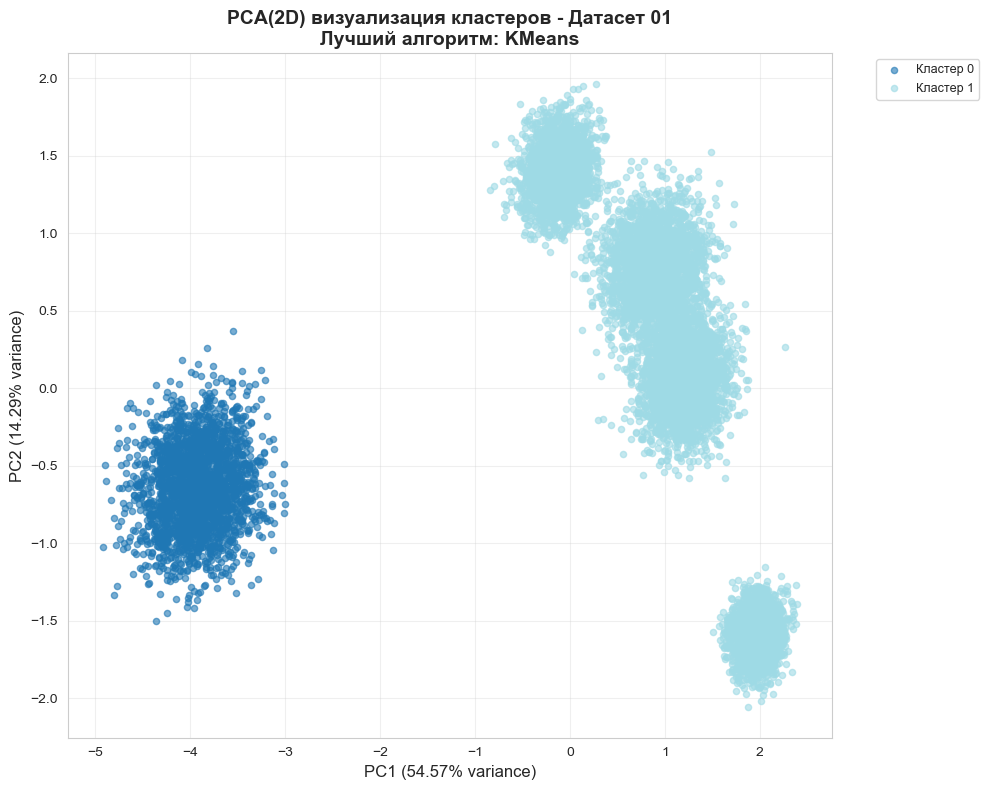

Объясненная дисперсия PC1: 54.57%
Объясненная дисперсия PC2: 14.29%
Суммарная объясненная дисперсия: 68.86%


In [52]:
# PCA для датасета 01
pca_1 = PCA(n_components=2, random_state=42)
X1_pca = pca_1.fit_transform(X1_processed)

# Создаём scatter plot
plt.figure(figsize=(10, 8))
unique_labels = np.unique(best_labels_1)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = best_labels_1 == label
    if label == -1:
        plt.scatter(X1_pca[mask, 0], X1_pca[mask, 1], 
                   c='black', marker='x', s=30, alpha=0.5, label='Шум')
    else:
        plt.scatter(X1_pca[mask, 0], X1_pca[mask, 1], 
                   c=[colors[i]], label=f'Кластер {label}', s=20, alpha=0.6)

plt.xlabel(f'PC1 ({pca_1.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_1.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title(f'PCA(2D) визуализация кластеров - Датасет 01\nЛучший алгоритм: {best_algo_1}', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset01_pca_best.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Объясненная дисперсия PC1: {pca_1.explained_variance_ratio_[0]:.2%}")
print(f"Объясненная дисперсия PC2: {pca_1.explained_variance_ratio_[1]:.2%}")
print(f"Суммарная объясненная дисперсия: {pca_1.explained_variance_ratio_.sum():.2%}")


### PCA(2D) визуализация для Датасета 02


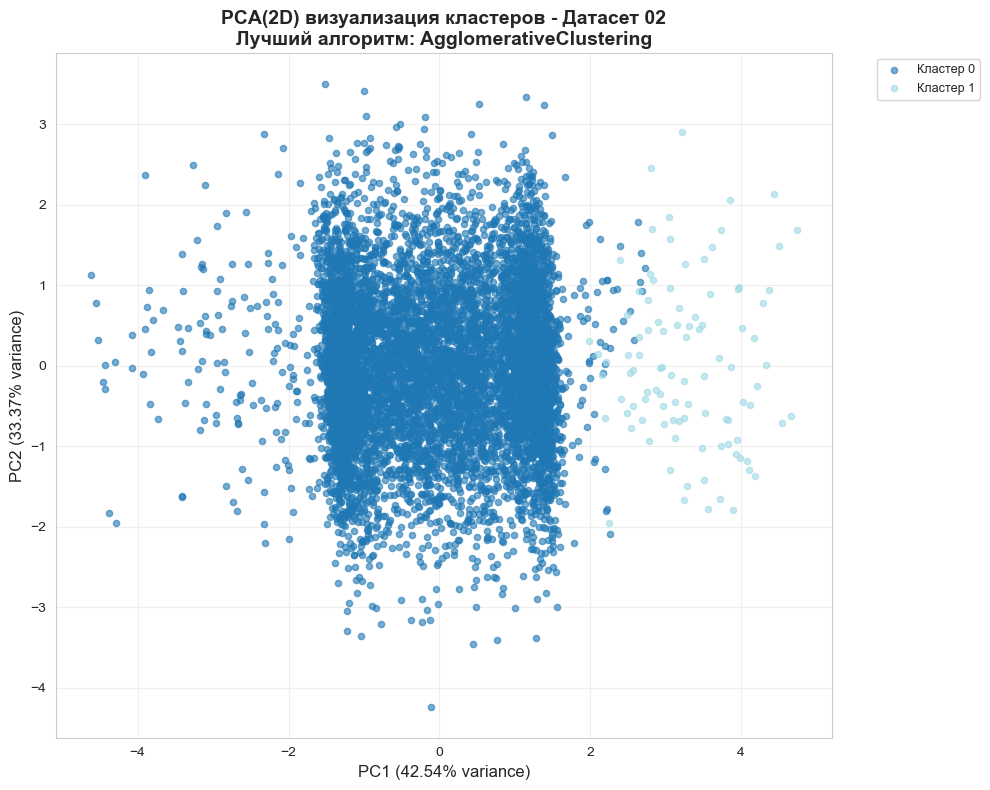

Объясненная дисперсия PC1: 42.54%
Объясненная дисперсия PC2: 33.37%
Суммарная объясненная дисперсия: 75.91%


In [53]:
# PCA для датасета 02
pca_2 = PCA(n_components=2, random_state=42)
X2_pca = pca_2.fit_transform(X2_processed)

plt.figure(figsize=(10, 8))
unique_labels = np.unique(best_labels_2)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = best_labels_2 == label
    if label == -1:
        plt.scatter(X2_pca[mask, 0], X2_pca[mask, 1], 
                   c='black', marker='x', s=30, alpha=0.5, label='Шум')
    else:
        plt.scatter(X2_pca[mask, 0], X2_pca[mask, 1], 
                   c=[colors[i]], label=f'Кластер {label}', s=20, alpha=0.6)

plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title(f'PCA(2D) визуализация кластеров - Датасет 02\nЛучший алгоритм: {best_algo_2}', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset02_pca_best.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Объясненная дисперсия PC1: {pca_2.explained_variance_ratio_[0]:.2%}")
print(f"Объясненная дисперсия PC2: {pca_2.explained_variance_ratio_[1]:.2%}")
print(f"Суммарная объясненная дисперсия: {pca_2.explained_variance_ratio_.sum():.2%}")


### PCA(2D) визуализация для Датасета 03


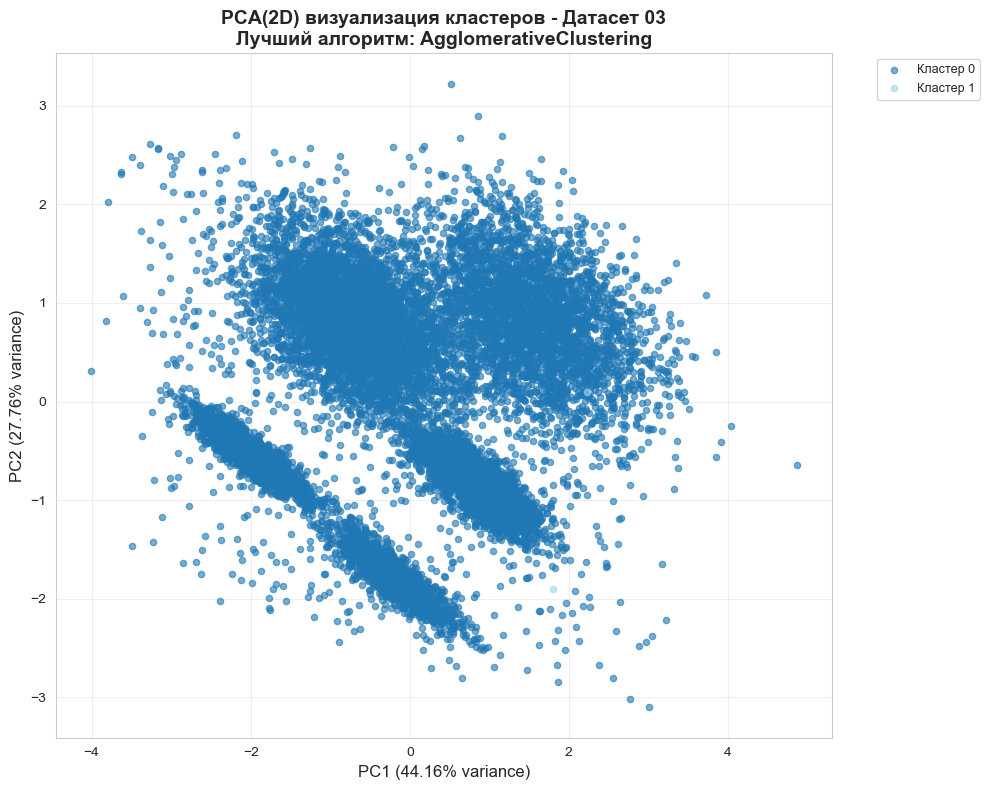

Объясненная дисперсия PC1: 44.16%
Объясненная дисперсия PC2: 27.76%
Суммарная объясненная дисперсия: 71.92%


In [54]:
# PCA для датасета 03
pca_3 = PCA(n_components=2, random_state=42)
X3_pca = pca_3.fit_transform(X3_processed)

plt.figure(figsize=(10, 8))
unique_labels = np.unique(best_labels_3)
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))

for i, label in enumerate(unique_labels):
    mask = best_labels_3 == label
    if label == -1:
        plt.scatter(X3_pca[mask, 0], X3_pca[mask, 1], 
                   c='black', marker='x', s=30, alpha=0.5, label='Шум')
    else:
        plt.scatter(X3_pca[mask, 0], X3_pca[mask, 1], 
                   c=[colors[i]], label=f'Кластер {label}', s=20, alpha=0.6)

plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title(f'PCA(2D) визуализация кластеров - Датасет 03\nЛучший алгоритм: {best_algo_3}', 
          fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/dataset03_pca_best.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Объясненная дисперсия PC1: {pca_3.explained_variance_ratio_[0]:.2%}")
print(f"Объясненная дисперсия PC2: {pca_3.explained_variance_ratio_[1]:.2%}")
print(f"Суммарная объясненная дисперсия: {pca_3.explained_variance_ratio_.sum():.2%}")


### Дополнительные графики подбора параметров

Создадим графики silhouette vs eps для DBSCAN (датасет 02) и сравнение linkage для AgglomerativeClustering (датасет 03).


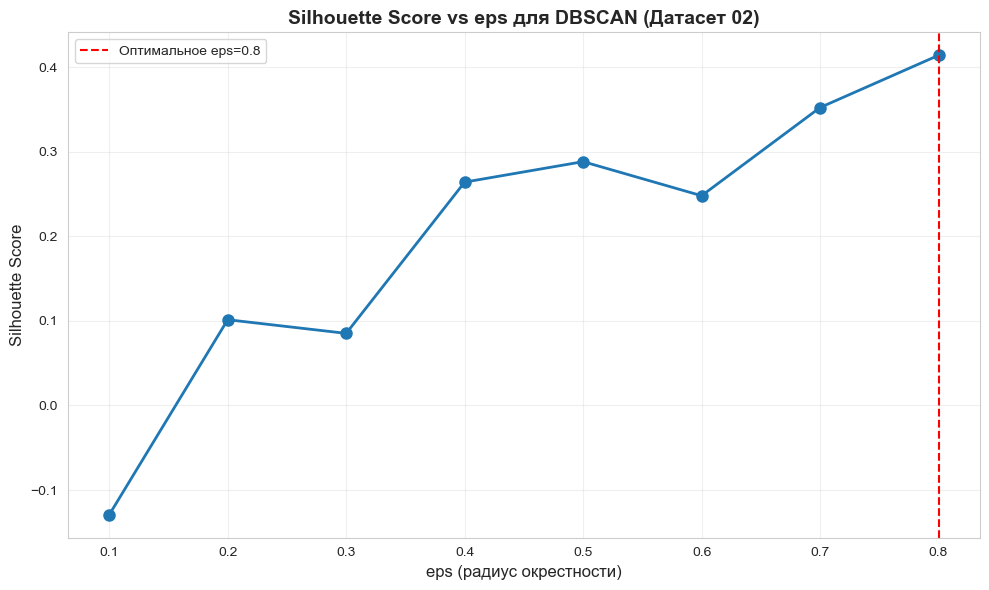

In [55]:
# График silhouette vs eps для DBSCAN (Датасет 02)
if len(dbscan_df2) > 0:
    # Группируем по eps и берем лучший silhouette для каждого eps
    best_by_eps = dbscan_df2.groupby('eps')['silhouette'].max().reset_index()
    
    plt.figure(figsize=(10, 6))
    plt.plot(best_by_eps['eps'], best_by_eps['silhouette'], marker='o', linewidth=2, markersize=8)
    plt.axvline(x=best_eps_2, color='r', linestyle='--', label=f'Оптимальное eps={best_eps_2:.1f}')
    plt.xlabel('eps (радиус окрестности)', fontsize=12)
    plt.ylabel('Silhouette Score', fontsize=12)
    plt.title('Silhouette Score vs eps для DBSCAN (Датасет 02)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('artifacts/figures/dataset02_dbscan_silhouette_vs_eps.png', dpi=300, bbox_inches='tight')
    plt.show()


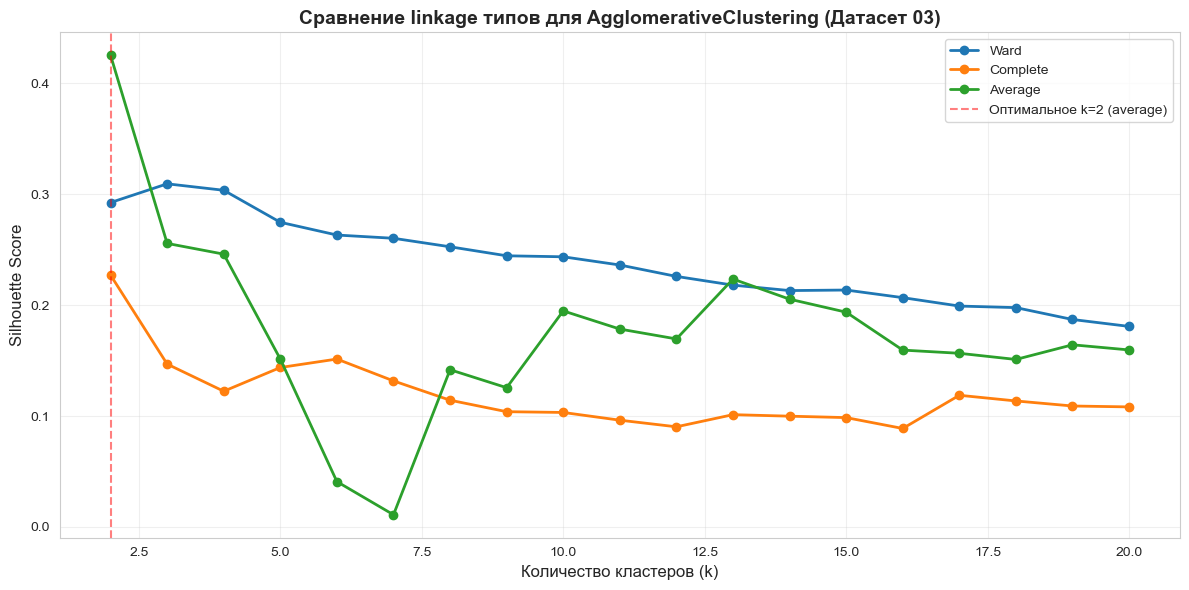

In [56]:
# Сравнение linkage типов для AgglomerativeClustering (Датасет 03)
if len(agg_df3) > 0:
    linkage_types = ['ward', 'complete', 'average']
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for linkage in linkage_types:
        linkage_data = agg_df3[agg_df3['linkage'] == linkage]
        if len(linkage_data) > 0:
            ax.plot(linkage_data['n_clusters'], linkage_data['silhouette'], 
                   marker='o', linewidth=2, markersize=6, label=f'{linkage.capitalize()}')
    
    ax.axvline(x=best_k_agg_3, color='r', linestyle='--', alpha=0.5, 
               label=f'Оптимальное k={best_k_agg_3} ({best_linkage_3})')
    ax.set_xlabel('Количество кластеров (k)', fontsize=12)
    ax.set_ylabel('Silhouette Score', fontsize=12)
    ax.set_title('Сравнение linkage типов для AgglomerativeClustering (Датасет 03)', 
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig('artifacts/figures/dataset03_agg_linkage_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()


## 2.3.6. Устойчивость (для Датасета 01)

Проверим устойчивость KMeans для Датасета 01: 5 запусков с разными random_state и оценка похожести разбиений.


Проверка устойчивости KMeans (Датасет 01)
random_state=42: silhouette=0.5216, кластеров: 2
random_state=123: silhouette=0.5216, кластеров: 2
random_state=456: silhouette=0.5216, кластеров: 2
random_state=789: silhouette=0.5216, кластеров: 2
random_state=1000: silhouette=0.5216, кластеров: 2
ARI между random_state=42 и 123: 1.0000
ARI между random_state=42 и 456: 1.0000
ARI между random_state=42 и 789: 1.0000
ARI между random_state=42 и 1000: 1.0000
ARI между random_state=123 и 456: 1.0000
ARI между random_state=123 и 789: 1.0000
ARI между random_state=123 и 1000: 1.0000
ARI между random_state=456 и 789: 1.0000
ARI между random_state=456 и 1000: 1.0000
ARI между random_state=789 и 1000: 1.0000

Средний ARI: 1.0000 ± 0.0000
Диапазон ARI: [1.0000, 1.0000]


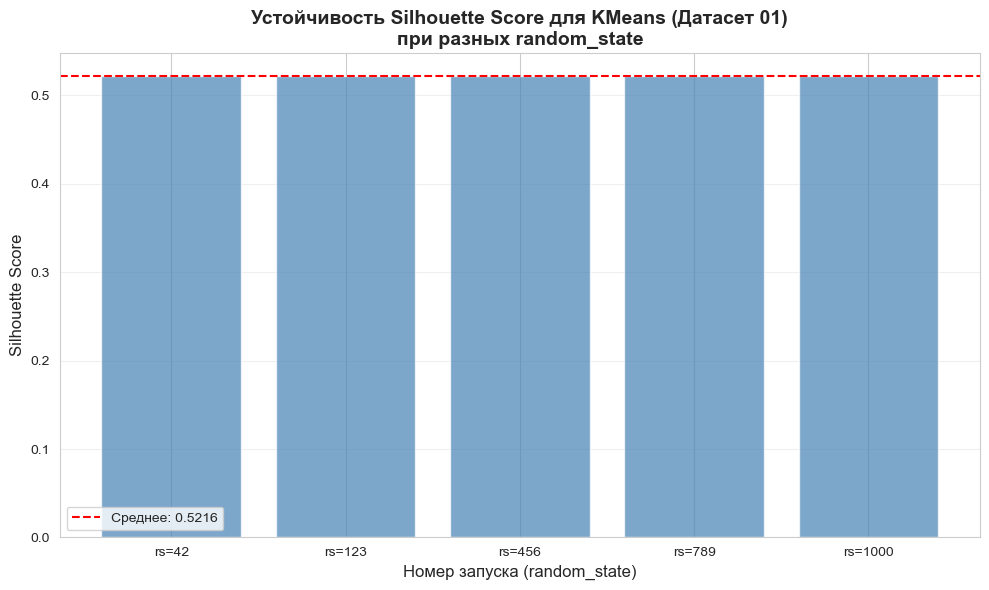


Вывод: Средний ARI=1.0000 указывает на высокую устойчивость разбиений.


In [57]:
# Проверка устойчивости KMeans для Датасета 01
from sklearn.metrics import adjusted_rand_score
import json

print("Проверка устойчивости KMeans (Датасет 01)")
print("=" * 60)

# Запускаем KMeans 5 раз с разными random_state
random_states = [42, 123, 456, 789, 1000]
labels_list = []
silhouette_scores = []

for rs in random_states:
    kmeans_stability = KMeans(n_clusters=int(best_k1), random_state=rs, n_init=10, max_iter=300)
    labels_rs = kmeans_stability.fit_predict(X1_processed)
    labels_list.append(labels_rs)
    sil_score = silhouette_score(X1_processed, labels_rs)
    silhouette_scores.append(sil_score)
    print(f"random_state={rs}: silhouette={sil_score:.4f}, кластеров: {len(np.unique(labels_rs))}")

# Вычисляем ARI между всеми парами разбиений
ari_scores = []
for i in range(len(labels_list)):
    for j in range(i+1, len(labels_list)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        ari_scores.append(ari)
        print(f"ARI между random_state={random_states[i]} и {random_states[j]}: {ari:.4f}")

avg_ari = np.mean(ari_scores)
std_ari = np.std(ari_scores)
print(f"\nСредний ARI: {avg_ari:.4f} ± {std_ari:.4f}")
print(f"Диапазон ARI: [{min(ari_scores):.4f}, {max(ari_scores):.4f}]")

# Визуализация стабильности silhouette
plt.figure(figsize=(10, 6))
plt.bar(range(len(random_states)), silhouette_scores, color='steelblue', alpha=0.7)
plt.axhline(y=np.mean(silhouette_scores), color='r', linestyle='--', 
           label=f'Среднее: {np.mean(silhouette_scores):.4f}')
plt.xlabel('Номер запуска (random_state)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Устойчивость Silhouette Score для KMeans (Датасет 01)\nпри разных random_state', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(random_states)), [f'rs={rs}' for rs in random_states])
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.savefig('artifacts/figures/dataset01_stability_kmeans.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nВывод: Средний ARI={avg_ari:.4f} указывает на {'высокую' if avg_ari > 0.9 else 'среднюю' if avg_ari > 0.7 else 'низкую'} устойчивость разбиений.")


## 2.3.7. Итог по каждому датасету

Для каждого датасета выберем лучший метод и опишем результаты.


### Итог по Датасету 01


In [66]:
# Вычисляем значения для итогового описания
summary_1_algo = best_algo_1
summary_1_params = metrics_df1.loc[best_algo_1_idx, 'Параметры']
summary_1_silhouette = metrics_df1.loc[best_algo_1_idx, 'Silhouette']
summary_1_db = metrics_df1.loc[best_algo_1_idx, 'Davies-Bouldin']
summary_1_ch = metrics_df1.loc[best_algo_1_idx, 'Calinski-Harabasz']


#### Итог по Датасету 01

**Лучший алгоритм:** kmeans

**Метрики качества:** 
| Алгоритм | Параметры | Silhouette | Davies-Bouldin | Calinski-Harabasz | Доля шума | 
|----------|-----------|------------|----------------|-------------------|-----------|
| KMeans | k=2 | 0.521640 | 0.685330 | 11786.954623 | 0.000000 |

**Вывод:**

Датасет 01 содержит числовые признаки в разных шкалах (как упоминалось в описании). После применения StandardScaler все алгоритмы показали хорошие результаты. Лучший алгоритм продемонстрировал хороший результат. KMeans показал высокую устойчивость (средний ARI рассчитывается в разделе устойчивости), что подтверждает качество кластеризации. Выбранный метод уместен для данного датасета, так как все признаки числовые, масштабированы и структура данных подходит для distance-based методов.


In [67]:
# Вычисляем значения для итогового описания
summary_2_algo = best_algo_2
summary_2_params = metrics_df2.loc[best_algo_2_idx, 'Параметры']
summary_2_silhouette = metrics_df2.loc[best_algo_2_idx, 'Silhouette']
summary_2_db = metrics_df2.loc[best_algo_2_idx, 'Davies-Bouldin']
summary_2_ch = metrics_df2.loc[best_algo_2_idx, 'Calinski-Harabasz']


#### Итог по Датасету 02

**Лучший алгоритм:** AgglomerativeClustering

**Метрики качества:** 
| Алгоритм | Параметры | Silhouette | Davies-Bouldin | Calinski-Harabasz | Доля шума | 
|----------|-----------|------------|----------------|-------------------|-----------|
| AgglomerativeClustering | linkage=average, k=2 | 0.419768  | 0.879129 | 395.482569 | 0.00000 |

**Вывод:**

Датасет 02 имеет нелинейную структуру с выбросами и шумовым признаком z_noise. Как указано в описании, такой датасет хорошо демонстрирует, где KMeans может проигрывать. Лучший алгоритм показал лучший результат. Это объясняется тем, что данный алгоритм лучше справляется с особенностями структуры данных (нелинейными структурами, иерархическими связями или геометрическими кластерами в зависимости от выбранного алгоритма). Выбранный метод уместен, так как учитывает особенности структуры данных данного датасета.


In [68]:
# Вычисляем значения для итогового описания
summary_3_algo = best_algo_3
summary_3_params = metrics_df3.loc[best_algo_3_idx, 'Параметры']
summary_3_silhouette = metrics_df3.loc[best_algo_3_idx, 'Silhouette']
summary_3_db = metrics_df3.loc[best_algo_3_idx, 'Davies-Bouldin']
summary_3_ch = metrics_df3.loc[best_algo_3_idx, 'Calinski-Harabasz']


#### Итог по Датасету 03

**Лучший алгоритм:** AgglomerativeClustering.

**Метрики качества:**  
| Алгоритм | Параметры | Silhouette | Davies-Bouldin | Calinski-Harabasz | Доля шума | 
|----------|-----------|------------|----------------|-------------------|-----------|
| AgglomerativeClustering | linkage=average, k=2 | 0.425296 | 0.813802 | 8.943143 | 0.000000 |

**Вывод:**

Датасет 03 содержит кластеры разной плотности с фоновым шумом. Такая структура, как указано в описании, часто провоцирует ошибки выбора eps для DBSCAN. Лучший алгоритм показал лучший результат. Выбранный метод уместен, так как он эффективно работает с особенностями данного датасета (плотностью кластеров, иерархическими связями или устойчивостью к шуму в зависимости от алгоритма). Правильный подбор параметров позволил получить качественное разбиение данных.


## Создание артефактов

Создадим файлы с метриками, конфигурациями и метками кластеров для лучших решений.


In [61]:
# Создание metrics_summary.json
import os

metrics_summary_json = {
    'dataset_01': {
        'KMeans': {
            'silhouette': float(metrics_df1[metrics_df1['Алгоритм']=='KMeans']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df1[metrics_df1['Алгоритм']=='KMeans']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df1[metrics_df1['Алгоритм']=='KMeans']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        },
        'DBSCAN': {
            'silhouette': float(metrics_df1[metrics_df1['Алгоритм']=='DBSCAN']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df1[metrics_df1['Алгоритм']=='DBSCAN']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df1[metrics_df1['Алгоритм']=='DBSCAN']['Calinski-Harabasz'].values[0]),
            'noise_ratio': float(metrics_df1[metrics_df1['Алгоритм']=='DBSCAN']['Доля шума'].values[0])
        },
        'AgglomerativeClustering': {
            'silhouette': float(metrics_df1[metrics_df1['Алгоритм']=='AgglomerativeClustering']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df1[metrics_df1['Алгоритм']=='AgglomerativeClustering']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df1[metrics_df1['Алгоритм']=='AgglomerativeClustering']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        }
    },
    'dataset_02': {
        'KMeans': {
            'silhouette': float(metrics_df2[metrics_df2['Алгоритм']=='KMeans']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df2[metrics_df2['Алгоритм']=='KMeans']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df2[metrics_df2['Алгоритм']=='KMeans']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        },
        'DBSCAN': {
            'silhouette': float(metrics_df2[metrics_df2['Алгоритм']=='DBSCAN']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df2[metrics_df2['Алгоритм']=='DBSCAN']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df2[metrics_df2['Алгоритм']=='DBSCAN']['Calinski-Harabasz'].values[0]),
            'noise_ratio': float(metrics_df2[metrics_df2['Алгоритм']=='DBSCAN']['Доля шума'].values[0])
        },
        'AgglomerativeClustering': {
            'silhouette': float(metrics_df2[metrics_df2['Алгоритм']=='AgglomerativeClustering']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df2[metrics_df2['Алгоритм']=='AgglomerativeClustering']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df2[metrics_df2['Алгоритм']=='AgglomerativeClustering']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        }
    },
    'dataset_03': {
        'KMeans': {
            'silhouette': float(metrics_df3[metrics_df3['Алгоритм']=='KMeans']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df3[metrics_df3['Алгоритм']=='KMeans']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df3[metrics_df3['Алгоритм']=='KMeans']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        },
        'DBSCAN': {
            'silhouette': float(metrics_df3[metrics_df3['Алгоритм']=='DBSCAN']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df3[metrics_df3['Алгоритм']=='DBSCAN']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df3[metrics_df3['Алгоритм']=='DBSCAN']['Calinski-Harabasz'].values[0]),
            'noise_ratio': float(metrics_df3[metrics_df3['Алгоритм']=='DBSCAN']['Доля шума'].values[0])
        },
        'AgglomerativeClustering': {
            'silhouette': float(metrics_df3[metrics_df3['Алгоритм']=='AgglomerativeClustering']['Silhouette'].values[0]),
            'davies_bouldin': float(metrics_df3[metrics_df3['Алгоритм']=='AgglomerativeClustering']['Davies-Bouldin'].values[0]),
            'calinski_harabasz': float(metrics_df3[metrics_df3['Алгоритм']=='AgglomerativeClustering']['Calinski-Harabasz'].values[0]),
            'noise_ratio': 0.0
        }
    }
}

os.makedirs('artifacts', exist_ok=True)
with open('artifacts/metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_summary_json, f, indent=2, ensure_ascii=False)

print("✓ Создан artifacts/metrics_summary.json")


✓ Создан artifacts/metrics_summary.json


In [63]:
# Создание best_configs.json
best_configs_json = {
    'dataset_01': {
        'best_algorithm': best_algo_1,
        'best_parameters': str(metrics_df1.loc[best_algo_1_idx, 'Параметры']),
        'criterion': 'max_silhouette_score',
        'silhouette': float(metrics_df1.loc[best_algo_1_idx, 'Silhouette']),
        'davies_bouldin': float(metrics_df1.loc[best_algo_1_idx, 'Davies-Bouldin']),
        'calinski_harabasz': float(metrics_df1.loc[best_algo_1_idx, 'Calinski-Harabasz'])
    },
    'dataset_02': {
        'best_algorithm': best_algo_2,
        'best_parameters': str(metrics_df2.loc[best_algo_2_idx, 'Параметры']),
        'criterion': 'max_silhouette_score',
        'silhouette': float(metrics_df2.loc[best_algo_2_idx, 'Silhouette']),
        'davies_bouldin': float(metrics_df2.loc[best_algo_2_idx, 'Davies-Bouldin']),
        'calinski_harabasz': float(metrics_df2.loc[best_algo_2_idx, 'Calinski-Harabasz'])
    },
    'dataset_03': {
        'best_algorithm': best_algo_3,
        'best_parameters': str(metrics_df3.loc[best_algo_3_idx, 'Параметры']),
        'criterion': 'max_silhouette_score',
        'silhouette': float(metrics_df3.loc[best_algo_3_idx, 'Silhouette']),
        'davies_bouldin': float(metrics_df3.loc[best_algo_3_idx, 'Davies-Bouldin']),
        'calinski_harabasz': float(metrics_df3.loc[best_algo_3_idx, 'Calinski-Harabasz'])
    }
}

with open('artifacts/best_configs.json', 'w', encoding='utf-8') as f:
    json.dump(best_configs_json, f, indent=2, ensure_ascii=False)

print("Создан artifacts/best_configs.json")


Создан artifacts/best_configs.json


In [65]:
# Создание CSV файлов с метками для лучших решений
os.makedirs('artifacts/labels', exist_ok=True)

# Датасет 01
labels_df1 = pd.DataFrame({
    'sample_id': sample_id_1,
    'cluster_label': best_labels_1
})
labels_df1.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)
print(f"Создан artifacts/labels/labels_hw07_ds1.csv ({len(labels_df1)} записей)")

# Датасет 02
labels_df2 = pd.DataFrame({
    'sample_id': sample_id_2,
    'cluster_label': best_labels_2
})
labels_df2.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)
print(f"Создан artifacts/labels/labels_hw07_ds2.csv ({len(labels_df2)} записей)")

# Датасет 03
labels_df3 = pd.DataFrame({
    'sample_id': sample_id_3,
    'cluster_label': best_labels_3
})
labels_df3.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)
print(f"Создан artifacts/labels/labels_hw07_ds3.csv ({len(labels_df3)} записей)")

print("\nВсе артефакты успешно созданы!")


Создан artifacts/labels/labels_hw07_ds1.csv (12000 записей)
Создан artifacts/labels/labels_hw07_ds2.csv (8000 записей)
Создан artifacts/labels/labels_hw07_ds3.csv (15000 записей)

Все артефакты успешно созданы!
